In [35]:
## HOMEWORK 3------
### I mean homework 5, but better, I added interpolation
### (o゜▽゜)o☆ Because I hate myself at times.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from scipy.interpolate import interp1d

In [31]:
# Constants
L = 10  # m
g = 10  # m/s^2

# Equations of Motion
def acceleration(theta):
    return - (g / L) * np.sin(theta)

# Runge-Kutta Method for Integration
def runge_kutta(theta0, omega0, dt, t_max):
    t_vals = np.arange(0, t_max, dt)
    theta_vals = np.zeros_like(t_vals)
    omega_vals = np.zeros_like(t_vals)
    
    theta_vals[0] = theta0
    omega_vals[0] = omega0

    for i in range(1, len(t_vals)):
        k1_theta = dt * omega_vals[i-1]
        k1_omega = dt * acceleration(theta_vals[i-1])
        
        k2_theta = dt * (omega_vals[i-1] + 0.5 * k1_omega)
        k2_omega = dt * acceleration(theta_vals[i-1] + 0.5 * k1_theta)
        
        k3_theta = dt * (omega_vals[i-1] + 0.5 * k2_omega)
        k3_omega = dt * acceleration(theta_vals[i-1] + 0.5 * k2_theta)
        
        k4_theta = dt * (omega_vals[i-1] + k3_omega)
        k4_omega = dt * acceleration(theta_vals[i-1] + k3_theta)
        
        theta_vals[i] = theta_vals[i-1] + (k1_theta + 2*k2_theta + 2*k3_theta + k4_theta) / 6
        omega_vals[i] = omega_vals[i-1] + (k1_omega + 2*k2_omega + 2*k3_omega + k4_omega) / 6
    
    return t_vals, theta_vals

# Compute FFT and Plot with Interpolation
def compute_fft(theta_vals, dt, title):
    N = len(theta_vals)
    t_vals = np.linspace(0, (N-1)*dt, N)
    
    # Interpolation for smoother FFT
    interp_factor = 10  # Interpolation factor
    interp_func = interp1d(t_vals, theta_vals, kind='cubic')
    t_interp = np.linspace(0, (N-1)*dt, interp_factor * N)  # Higher resolution
    theta_interp = interp_func(t_interp)
    
    print(f"Number of interpolated points: {interp_factor * N - N}")
    
    fft_vals = rfft(theta_interp)
    freqs = rfftfreq(len(t_interp), dt / interp_factor)
    
    plt.figure(figsize=(8, 6))
    plt.plot(freqs, np.abs(fft_vals), label='FFT Magnitude')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("|Theta_k|")
    plt.title(f"FFT of Pendulum Motion ({title})")
    plt.legend()
    plt.show()

Number of interpolated points: 900


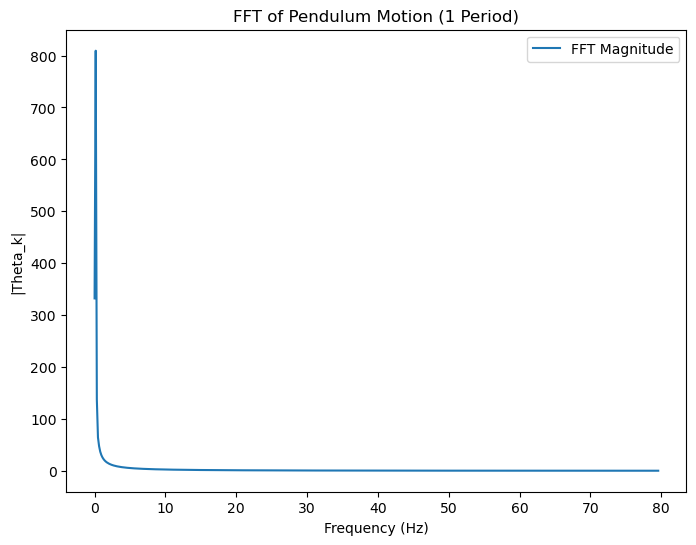

Number of interpolated points: 9000


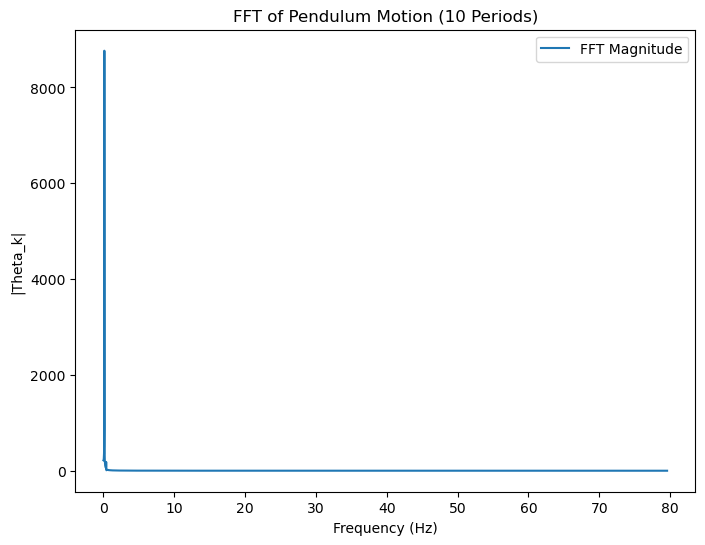

In [33]:
# Initial conditions
theta0 = np.radians(100)  # 100 degrees
omega0 = 0  # Starting from rest

# Small-angle approximation period
T_small_angle = 2 * np.pi * np.sqrt(L / g)

dt = T_small_angle / 100  # High resolution

# Run for 1 period
t_vals_1p, theta_vals_1p = runge_kutta(theta0, omega0, dt, T_small_angle)
compute_fft(theta_vals_1p, dt, "1 Period")

# Run for 10 periods
t_vals_10p, theta_vals_10p = runge_kutta(theta0, omega0, dt, 10 * T_small_angle)
compute_fft(theta_vals_10p, dt, "10 Periods")